In [1]:
pip install numpy scipy soundfile matplotlib

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\apps\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, spectrogram, resample_poly

By the end of this section, students will be able to generate a reverberant signal by convolving audio with a measured room impulse response and estimate reverberation time (T20/T30 and RT60) from the impulse response using a Schroeder energy decay curve and linear decay fitting.

Why does convolving the clean signal $x[n]$ with the room impulse response $h[n]$ produce a reverberant signal $y[n]$? In your answer, explain what information $h[n]$ encodes physically and how that shows up in the time-domain tail and the spectrogram.

x shape: (233873,)
h shape: (354123,)
fs_x: 48000
fs_h: 44100
Using sample rate: 48000
len(x): 233873
len(h): 385440
len(y_norm): 619312


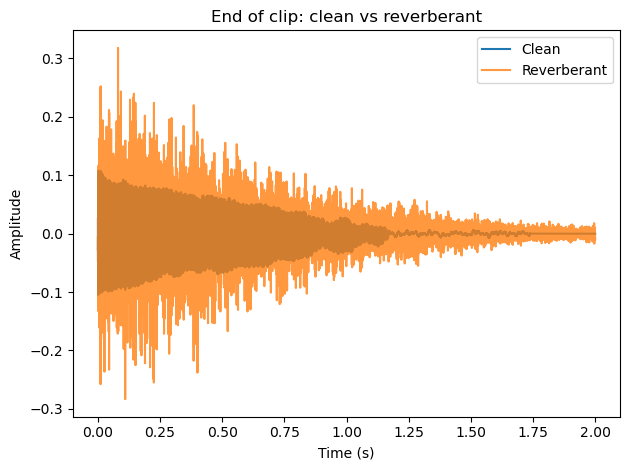

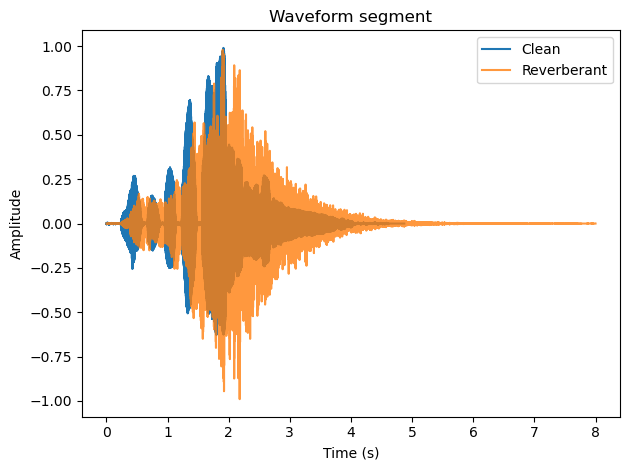

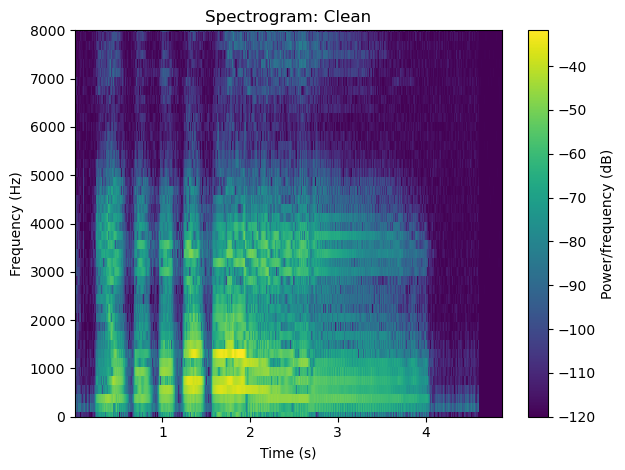

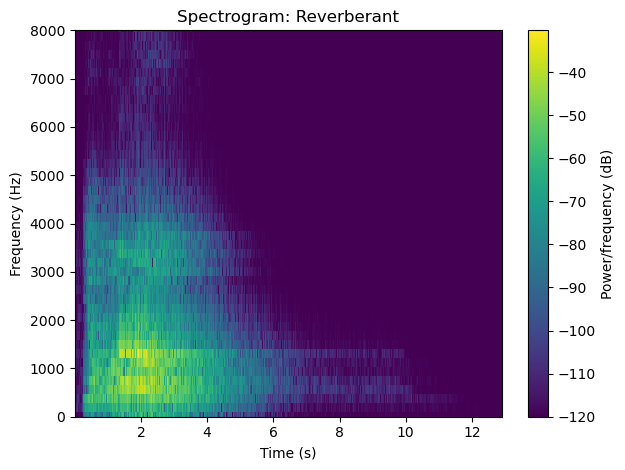

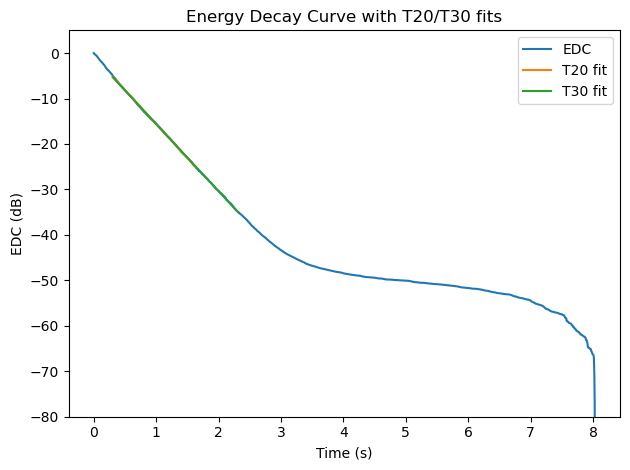

T20: 1.34 s
T30: 2.03 s
RT60 from T20 fit: 4.02 s
RT60 from T30 fit: 4.06 s


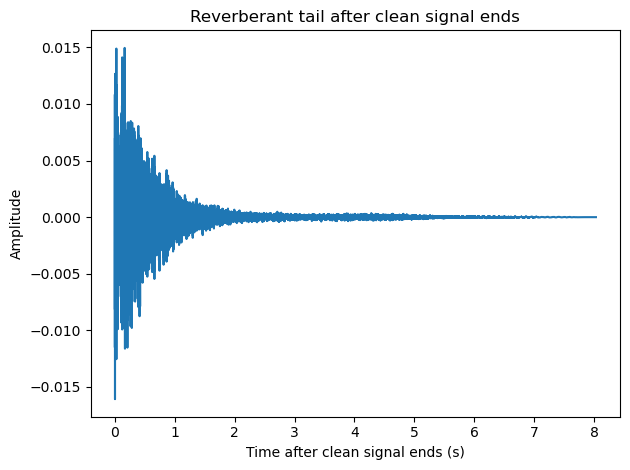

In [5]:
# Convolution Reverb and RT60 Estimation
# Goals:
# - convolve clean audio with a room impulse response
# - plot waveform and spectrogram differences
# - compute Schroeder EDC
# - estimate T20, T30, and RT60

def to_mono(x):
    """Convert mono/stereo/multichannel audio to mono."""
    if x.ndim == 1:
        return x
    if x.ndim == 2:
        return np.mean(x, axis=1) if x.shape[1] <= 8 else np.mean(x, axis=0)
    raise ValueError(f"Unsupported audio shape: {x.shape}")


def peak_normalise(x, peak=0.99):
    """Scale signal so max absolute amplitude is `peak`."""
    # TODO: compute max absolute value
    max_abs = np.max(np.abs(x))

    # TODO: avoid divide-by-zero
    max_abs_safe = max_abs if max_abs > 0 else 1.0

    # TODO: scale signal
    return (x / max_abs_safe) * peak


def schroeder_edc_db(h):
    """Compute Schroeder Energy Decay Curve in dB."""
    # TODO: energy = h squared
    energy = h ** 2

    # TODO: reverse cumulative sum
    edc = np.cumsum(energy[::-1])[::-1]

    # TODO: normalise to peak = 1
    edc = edc / np.max(edc)

    # TODO: convert to dB using 10*log10
    edc_db = 10 * np.log10(edc + 1e-12)

    return edc_db


def fit_decay_time(edc_db, fs, fit_range_db=(-5, -25)):
    """Fit y = a*t + b to EDC over a dB range."""
    t = np.arange(len(edc_db)) / fs
    hi_db, lo_db = fit_range_db

    # TODO: select EDC values between hi_db and lo_db
    idx = np.where((edc_db <= hi_db) & (edc_db >= lo_db))[0]

    if idx is None or len(idx) < 10:
        return np.nan, np.nan, np.array([], dtype=int)

    # TODO: get selected time and EDC values
    tt = t[idx]
    yy = edc_db[idx]

    # TODO: build least-squares matrix [t, 1]
    A = np.vstack([tt, np.ones(len(tt))]).T

    # TODO: solve for slope a and intercept b
    a, b = np.linalg.lstsq(A, yy, rcond=None)[0]

    return a, b, idx


def estimate_reverb_times(h, fs):
    """Estimate T20, T30, and RT60 from an impulse response."""
    # TODO: compute EDC
    edc_db = schroeder_edc_db(h)

    # TODO: T20 fit, -5 to -25 dB
    a20, b20, idx20 = fit_decay_time(edc_db, fs, fit_range_db=(-5, -25))

    # TODO: measured T20 and extrapolated RT60
    t20 = -20 / a20 if a20 < 0 else np.nan
    rt60_from_t20 = t20 * 3

    # TODO: T30 fit, -5 to -35 dB
    a30, b30, idx30 = fit_decay_time(edc_db, fs, fit_range_db=(-5, -35))

    # TODO: measured T30 and extrapolated RT60
    t30 = -30 / a30 if a30 < 0 else np.nan
    rt60_from_t30 = t30 * 2

    return {
        "edc_db": edc_db,
        "T20": t20,
        "T30": t30,
        "RT60_from_T20_fit": rt60_from_t20,
        "RT60_from_T30_fit": rt60_from_t30,
        "idx20": idx20,
        "idx30": idx30,
        "a20": a20,
        "b20": b20,
        "a30": a30,
        "b30": b30,
    }


# 1. Load audio

clean_path = "singing.wav"
rir_path = "1a_marble_hall.wav"

# TODO: load audio files
x, fs_x = sf.read(clean_path)
h, fs_h = sf.read(rir_path)

# TODO: convert to mono float32
x = to_mono(x).astype(np.float32)
h = to_mono(h).astype(np.float32)

print("x shape:", x.shape)
print("h shape:", h.shape)
print("fs_x:", fs_x)
print("fs_h:", fs_h)

#2. Match sample rates

if fs_h != fs_x:
    # TODO: resample h to match fs_x
    g = np.gcd(fs_h, fs_x)
    up = fs_x // g
    down = fs_h // g
    h = resample_poly(h, up, down)
    fs_h = fs_x

fs = fs_x
print("Using sample rate:", fs)

# 3. Remove DC and normalise

# TODO: remove mean from h and peak-normalise
h = h - np.mean(h)
h = peak_normalise(h)

# TODO: remove mean from x and peak-normalise
x = x - np.mean(x)
x = peak_normalise(x)


#4. Generate reverberant signal

# TODO: convolve x and h using fftconvolve, mode="full"
y = fftconvolve(x, h, mode="full")

# TODO: peak-normalise output
y_norm = peak_normalise(y)

print("len(x):", len(x))
print("len(h):", len(h))
print("len(y_norm):", len(y_norm))


# 5. Plot waveforms


# End-of-clip comparison

dur_tail = 2.0
N_tail = int(dur_tail * fs)

start_x = max(0, len(x) - N_tail)
start_y = start_x

seg_x = x[start_x:start_x + N_tail]
seg_y = y_norm[start_y:start_y + N_tail]
t_tail = np.arange(len(seg_x)) / fs

plt.figure()

# TODO: plot clean and reverberant tail
plt.plot(t_tail, seg_x, label="Clean")
plt.plot(t_tail, seg_y, label="Reverberant", alpha=0.8)

plt.title("End of clip: clean vs reverberant")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


# First few seconds

dur_wave = 8.0
N_wave = int(dur_wave * fs)

t_x = np.arange(min(len(x), N_wave)) / fs
t_y = np.arange(min(len(y_norm), N_wave)) / fs

plt.figure()

# TODO: plot clean and reverberant waveform segment
plt.plot(t_x, x[:len(t_x)], label="Clean")
plt.plot(t_y, y_norm[:len(t_y)], label="Reverberant", alpha=0.8)

plt.title("Waveform segment")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()



# 6. Spectrograms

# TODO: compute spectrograms
f_x, t_spec_x, Sxx = spectrogram(x, fs)
f_y, t_spec_y, Syy = spectrogram(y_norm, fs)

plt.figure()

# TODO: plot clean spectrogram in dB
plt.pcolormesh(t_spec_x, f_x, 10*np.log10(Sxx + 1e-12), shading="auto")

plt.ylim(0, 8000)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram: Clean")
plt.colorbar(label="Power/frequency (dB)")
plt.tight_layout()
plt.show()

plt.figure()

# TODO: plot reverberant spectrogram in dB
plt.pcolormesh(t_spec_y, f_y, 10*np.log10(Syy + 1e-12), shading="auto")

plt.ylim(0, 8000)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram: Reverberant")
plt.colorbar(label="Power/frequency (dB)")
plt.tight_layout()
plt.show()



# 7. Estimate reverberation time


# TODO: estimate reverb times
res = estimate_reverb_times(h, fs)

# TODO: create EDC time axis
t_edc = np.arange(len(res["edc_db"])) / fs
edc_db = res["edc_db"]

plt.figure()

# TODO: plot EDC
plt.plot(t_edc, edc_db, label="EDC")

plt.ylim(-80, 5)
plt.xlabel("Time (s)")
plt.ylabel("EDC (dB)")
plt.title("Energy Decay Curve with T20/T30 fits")

# TODO: plot T20 fit
if res is not None and np.isfinite(res["a20"]) and len(res["idx20"]) > 0:
    tt = t_edc[res["idx20"]]
    plt.plot(tt, res["a20"]*tt + res["b20"], label="T20 fit")

# TODO: plot T30 fit
if res is not None and np.isfinite(res["a30"]) and len(res["idx30"]) > 0:
    tt = t_edc[res["idx30"]]
    plt.plot(tt, res["a30"]*tt + res["b30"], label="T30 fit")

plt.legend()
plt.tight_layout()
plt.show()


# TODO: print results
print(f"T20: {res['T20']:.2f} s")
print(f"T30: {res['T30']:.2f} s")
print(f"RT60 from T20 fit: {res['RT60_from_T20_fit']:.2f} s")
print(f"RT60 from T30 fit: {res['RT60_from_T30_fit']:.2f} s")



# Questions
# 1. Why does convolving x[n] with h[n] create reverberation?
# 2. What physical information does the room impulse response contain?
# 3. What changes do you see in the waveform?
# 4. What changes do you see in the spectrogram?
# 5. Are the RT60 estimates from T20 and T30 similar? Why might they differ?


# Extension: plot the post-source reverb tail


# TODO: plot y_norm from index len(x) onward
tail = y_norm[len(x):]
t_tail_after = np.arange(len(tail)) / fs
plt.figure()
plt.plot(t_tail_after, tail)
plt.title("Reverberant tail after clean signal ends")
plt.xlabel("Time after clean signal ends (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

Students will be able to distinguish linear and circular convolution, and explain how insufficient zero-padding as too-small FFT length N causes time-domain wrap-around problems.

What condition on the FFT length N guarantees that FFT-based multiplication produces the linear convolution rather than circular convolution, and what time-domain problem do you observe when the condition is violated?

Lx: 233873
Lh: 385440
Ly: 619312
Ly: 619312
N_wrong: 385440


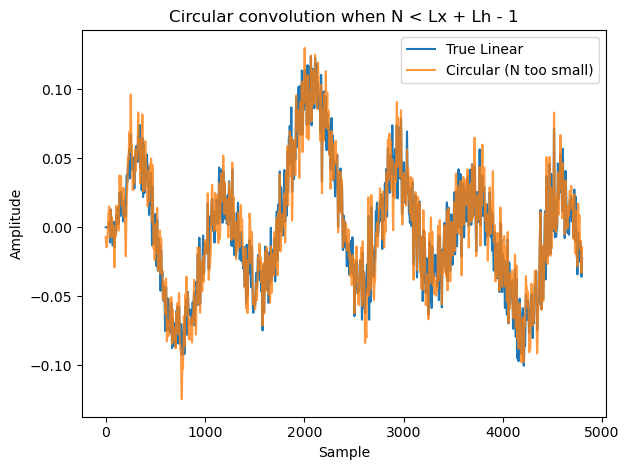

N_correct: 619312
Max error: 2.2084169430058864e-05


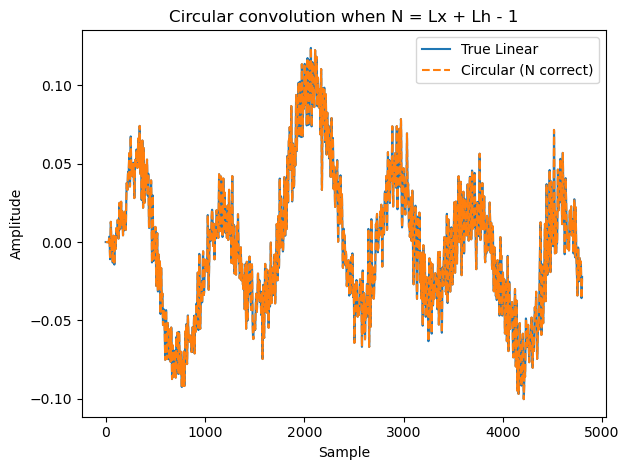

In [6]:
# Linear vs Circular Convolution
# In this section, you will compare:
# - true linear convolution
# - circular convolution using the FFT
# - what happens when the FFT length is too short

# Key idea:
# Linear convolution has length:
#     Ly = len(x) + len(h) - 1

# To avoid circular wrap-around, the FFT length N must satisfy:
#     N >= Ly


def linear_conv_fftconvolve(x, h):
    """
    Compute full linear convolution using fftconvolve.
    """
    # TODO: use fftconvolve with mode="full"
    y = fftconvolve(x, h, mode="full")

    return y

def circular_conv_fft(x, h, N):
    """
    Compute circular convolution of length N using FFTs.
    """
    # TODO: compute N-point FFT of x
    X = np.fft.fft(x, n=N)

    # TODO: compute N-point FFT of h
    H = np.fft.fft(h, n=N)

    # TODO: multiply spectra
    Y = X * H

    # TODO: inverse FFT and take real part
    y = np.real(np.fft.ifft(Y))

    return y


# x, h, and fs should already be defined from the previous part of the lab.

# TODO: compute true linear convolution
y_linear = linear_conv_fftconvolve(x, h)

# TODO: compute signal lengths
Lx = len(x)
Lh = len(h)

# TODO: compute required full linear convolution length
Ly = Lx + Lh - 1

print("Lx:", Lx)
print("Lh:", Lh)
print("Ly:", Ly)



# Choose an FFT length that is too small.
# This should cause circular wrap-around.

# TODO: choose N_wrong as max(Lx, Lh)
N_wrong = max(Lx, Lh)

if N_wrong >= Ly:
    N_wrong = Ly - 1

# TODO: compute circular convolution with N_wrong
y_circ_wrong = circular_conv_fft(x, h, N_wrong)

print("Ly:", Ly)
print("N_wrong:", N_wrong)


# Plot incorrect circular convolution against true linear convolution

dur = 0.1
Nplot = int(dur * fs)

plt.figure()

# TODO: plot first Nplot samples of y_linear
plt.plot(y_linear[:Nplot], label="True Linear")

# TODO: plot first Nplot samples of y_circ_wrong
plt.plot(y_circ_wrong[:Nplot], label="Circular (N too small)", alpha=0.8)

plt.title("Circular convolution when N < Lx + Lh - 1")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()



# Now choose a correct FFT length.
# This should avoid circular wrap-around.

# TODO: set N_correct equal to Ly
N_correct = Ly

# TODO: compute circular convolution with N_correct
y_circ_correct = circular_conv_fft(x, h, N_correct)

# TODO: compute max absolute error between y_linear and y_circ_correct
max_error = np.max(np.abs(y_linear - y_circ_correct))

print("N_correct:", N_correct)
print("Max error:", max_error)



# Plot correct circular convolution against true linear convolution

plt.figure()

# TODO: plot first Nplot samples of y_linear
plt.plot(y_linear[:Nplot], label="True Linear")

# TODO: plot first Nplot samples of y_circ_correct
plt.plot(y_circ_correct[:Nplot], label="Circular (N correct)", linestyle="--")

plt.title("Circular convolution when N = Lx + Lh - 1")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

Students will be able to compute and interpret an impulse response’s magnitude response, unwrapped phase, and group delay from its FFT, and relate direct-arrival time and energy centroid to the temporal structure of the room impulse response.

Why does the group delay equal $\tau_g(\omega) = -\frac{d}{d\omega}\angle H(\omega)$, and what does a large positive group delay in a frequency band indicate about the impulse response in the time domain?

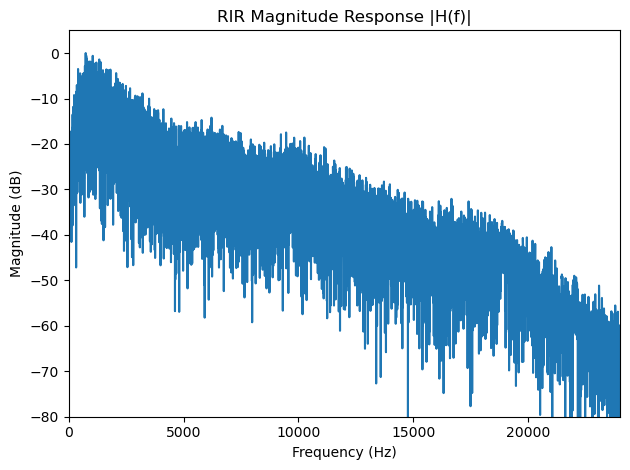

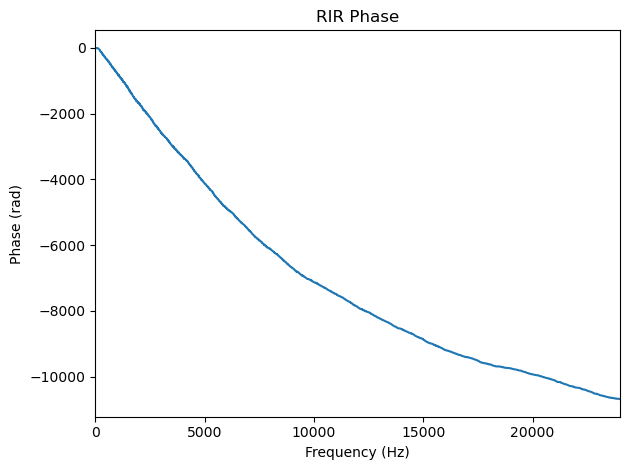

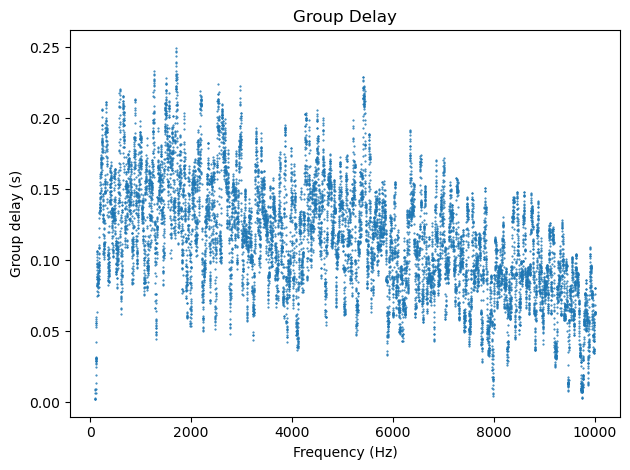

Direct arrival sample: 30
Direct arrival time: 0.000625 s
Energy centroid time: 0.2719942338730527 s


In [7]:
#RIR Magnitude, Phase, Group Delay, and Arrival Time

# In this section, you will analyse a room impulse response in the frequency domain.
# You will compute:
# - magnitude response
# - unwrapped phase
# - group delay
# - direct arrival time
# - energy centroid time

def moving_average(x, k):
    """
    Smooth a signal using a length-k moving average.
    """
    # TODO: create a length-k averaging kernel
    w = np.ones(k) / k

    # TODO: convolve x with w using mode="same"
    y = np.convolve(x, w, mode="same")

    return y


def rir_mag_phase_group_delay(
    h,
    fs,
    nfft=65536,
    mag_mask_db=40.0,
    fmin=100.0,
    fmax=10000.0,
    smooth_bins=31,
):
    """
    Compute magnitude, unwrapped phase, and group delay for a room impulse response.
    """
    h = np.asarray(h)

    # TODO: compute one-sided FFT of h
    H = np.fft.rfft(h, n=nfft)

    # TODO: create frequency axis for rFFT bins
    f = np.fft.rfftfreq(nfft, d=1.0/fs)

    # TODO: compute magnitude response
    mag = np.abs(H)

    # TODO: convert magnitude to dB
    mag_db = 20 * np.log10(mag + 1e-12)

    # TODO: normalise magnitude so that the peak is 0 dB
    mag_db_norm = mag_db - np.max(mag_db)

    # TODO: compute unwrapped phase
    phase_unw = np.unwrap(np.angle(H))

    # Optional phase smoothing
    if smooth_bins is not None and smooth_bins > 1:
        # TODO: smooth the unwrapped phase
        phase_s = moving_average(phase_unw, smooth_bins)
    else:
        phase_s = phase_unw

    # TODO: create angular frequency axis in rad/s
    omega = 2 * np.pi * f

    # TODO: compute group delay in seconds
    # group delay = - d phase / d omega
    gd_sec = -np.gradient(phase_s, omega[1] - omega[0])

    # TODO: keep bins within mag_mask_db of the peak
    mask_mag = mag_db_norm >= -mag_mask_db

    # TODO: keep bins inside frequency band [fmin, fmax]
    mask_band = (f >= fmin) & (f <= fmax)

    # TODO: combine both masks
    mask = mask_mag & mask_band

    return f, mag_db_norm, phase_unw, gd_sec, mask


# h and fs should already be defined.

f, mag_db_norm, phase_unw, gd_sec, mask = rir_mag_phase_group_delay(
    h,
    fs,
    nfft=65536,
    mag_mask_db=40.0,
    fmin=100.0,
    fmax=10000.0,
    smooth_bins=51,
)


# Plot magnitude response

plt.figure()

# TODO: plot magnitude response against frequency
plt.plot(f, mag_db_norm)

plt.xlim(0, fs / 2)
plt.ylim(-80, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("RIR Magnitude Response |H(f)|")
plt.tight_layout()
plt.show()



# Plot unwrapped phase

plt.figure()

# TODO: plot unwrapped phase against frequency
plt.plot(f, phase_unw)

plt.xlim(0, fs / 2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (rad)")
plt.title("RIR Phase")
plt.tight_layout()
plt.show()



# Plot group delay

plt.figure()

# TODO: plot masked group delay against frequency
plt.plot(f[mask], gd_sec[mask], '.', markersize=1)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Group delay (s)")
plt.title("Group Delay")
plt.tight_layout()
plt.show()


def estimate_direct_arrival(h, fs, thresh_db=-20.0):
    """
    Estimate direct arrival as the first sample above a threshold
    relative to the peak amplitude.
    """
    h = np.asarray(h)

    # TODO: compute absolute value of h
    a = np.abs(h)

    # TODO: compute peak absolute amplitude
    peak = np.max(a)

    # TODO: convert threshold from dB to linear amplitude
    thresh = peak * (10 ** (thresh_db / 20))

    # TODO: find indices where abs(h) is above threshold
    idx = np.where(a >= thresh)[0]

    if idx is None or len(idx) == 0:
        return None, None

    # TODO: take the first index
    n0 = idx[0]

    # TODO: convert sample index to time in seconds
    t0 = n0 / fs

    return n0, t0


# Estimate direct arrival

n0, t0 = estimate_direct_arrival(h, fs, thresh_db=-20.0)

print("Direct arrival sample:", n0)
print("Direct arrival time:", t0, "s")


# Energy centroid

# TODO: create time axis for h
t = np.arange(len(h)) / fs

# TODO: compute energy of h
e = h ** 2

# TODO: compute energy centroid time
t_centroid = np.sum(t * e) / np.sum(e)

print("Energy centroid time:", t_centroid, "s")



# Questions
# 1. What does the magnitude response tell you about the room?
# 2. Why do we unwrap the phase before computing group delay?
# 3. Why is the phase smoothed before differentiation?
# 4. Why do we mask low-magnitude frequency bins for group delay?
# 5. What is the difference between direct arrival time and energy centroid time?

Students will be able to implement frequency-domain deconvolution using a stabilised inverse filter and a Wiener-regularised filter

Why does dividing by $H(\omega)$ amplify noise at frequencies where $|H(\omega)|$ is small, and how does the Wiener regularisation term $\alpha$ mitigate this?



Students will be able to align and scale an estimated signal to a reference and quantify reconstruction quality using raw and aligned+scaled SNR while sweeping input noise level and Wiener regularisation strength.

In [8]:
# Deconvolution: Recovering x from y and h
# Earlier we created:
#     y = x * h
# In this section, we try to recover x from y using frequency-domain deconvolution.
# In the frequency domain:
#     Y(f) = X(f)H(f)
# So a simple inverse estimate is:
#     Xhat(f) = Y(f) / H(f)
# This can be unstable when H(f) is close to zero.


def next_pow2(n):
    """
    Return the next power of 2 greater than or equal to n.
    """
    # TODO: handle the case where n <= 1
    if n <= 1:
        return 1

    # TODO: return next power of 2 >= n
    return 2 ** int(np.ceil(np.log2(n)))

def add_awgn_snr(x, snr_db, rng=None):
    """
    Add white Gaussian noise to x at a target SNR in dB.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    # TODO: compute signal power
    p_sig = np.mean(x ** 2)

    # TODO: convert SNR from dB to noise power
    p_noise = p_sig / (10 ** (snr_db / 10))

    # TODO: generate Gaussian noise with variance p_noise
    noise = rng.normal(0, np.sqrt(p_noise), size=len(x))

    return x + noise, noise


def snr_db(ref, est):
    """
    Compute SNR in dB between a reference signal and an estimate.
    """
    # TODO: compute error
    e = ref - est

    # TODO: compute SNR in dB
    val = 10 * np.log10(np.sum(ref ** 2) / (np.sum(e ** 2) + 1e-12))

    return val


def nmse_db(ref, est):
    """
    Compute normalised mean squared error in dB.
    """
    # TODO: compute error
    e = ref - est

    # TODO: compute NMSE in dB
    val = 10 * np.log10(np.sum(e ** 2) / (np.sum(ref ** 2) + 1e-12))

    return val

def align_rir_to_direct(h, n0):
    """
    Shift RIR so that the direct arrival is at n = 0.
    """
    # TODO: roll h left by n0 samples
    h2 = np.roll(h, -n0)

    # TODO: zero the wrapped part at the end
    if n0 > 0:
        h2[-n0:] = 0

    return h2


def inv_deconv_freq(y, h, Lx, eps=1e-10, nfft=None):
    """
    Naive inverse deconvolution:

        Xhat = Y / (H + eps)
    """
    if nfft is None:
        # TODO: choose FFT size large enough for linear convolution
        nfft = next_pow2(len(y))

    # TODO: FFT of y
    Y = np.fft.fft(y, n=nfft)

    # TODO: FFT of h
    H = np.fft.fft(h, n=nfft)

    # TODO: divide by H with small eps
    Xhat = Y / (H + eps)

    # TODO: inverse FFT
    xhat = np.real(np.fft.ifft(Xhat))

    return xhat[:Lx]


def wiener_deconv_freq(y, h, Lx, alpha_rel=1e-4, nfft=None):
    """
    Wiener-regularised inverse:

        Xhat = (H* / (|H|^2 + alpha))Y
    """
    if nfft is None:
        # TODO: choose FFT size large enough
        nfft = next_pow2(len(y))

    # TODO: FFT of y
    Y = np.fft.fft(y, n=nfft)

    # TODO: FFT of h
    H = np.fft.fft(h, n=nfft)

    # TODO: compute |H|^2
    H2 = np.abs(H) ** 2

    # TODO: choose alpha relative to max |H|^2
    alpha = alpha_rel * np.max(H2)

    # TODO: build Wiener inverse filter
    G = np.conj(H) / (H2 + alpha)

    # TODO: apply inverse filter
    Xhat = G * Y

    # TODO: inverse FFT
    xhat = np.real(np.fft.ifft(Xhat))

    return xhat[:Lx], G


def best_scale(ref, est):
    """
    Find scalar a so that a * est best matches ref.
    """
    # TODO: compute least-squares scale factor
    a = np.sum(ref * est) / (np.sum(est ** 2) + 1e-12)

    return a


def align_by_xcorr(ref, est, max_shift=2000):
    """
    Align est to ref using cross-correlation.
    """
    # TODO: compute full cross-correlation
    c = np.correlate(ref, est, mode="full")

    # TODO: create lag axis
    lags = np.arange(-len(est) + 1, len(ref))

    # TODO: keep only lags within +/- max_shift
    mask = np.where((lags >= -max_shift) & (lags <= max_shift))[0]

    # TODO: find lag with maximum correlation
    lag = lags[mask[np.argmax(c[mask])]]

    # TODO: shift/crop signals based on lag
    if lag > 0:
        est_a = est[:len(ref)-lag]
        ref_a = ref[lag:lag+len(est_a)]
    elif lag < 0:
        est_a = est[-lag:len(ref)-lag]
        ref_a = ref[:len(est_a)]
    else:
        m = min(len(ref), len(est))
        est_a = est[:m]
        ref_a = ref[:m]

    m = min(len(ref_a), len(est_a))
    return ref_a[:m], est_a[:m], lag

def snr_db_aligned_scaled(ref, est, max_shift=2000):
    """
    Compute SNR after alignment and best amplitude scaling.
    """
    # TODO: align using cross-correlation
    ref_a, est_a, lag = align_by_xcorr(ref, est, max_shift)

    # TODO: compute best scale
    a = best_scale(ref_a, est_a)

    # TODO: compute SNR after scaling
    val = snr_db(ref_a, a * est_a)

    return val, lag, a


#Run naive inverse deconvolution

# x, y, h, fs, and estimate_direct_arrival should already be defined.

x_ref = x
Lx = len(x_ref)

# TODO: estimate direct arrival sample in h
n0, _ = estimate_direct_arrival(h, fs, thresh_db=-20.0)

# TODO: align RIR to direct arrival
h_use = align_rir_to_direct(h, n0)

# TODO: create a reverberant signal using the aligned RIR
y_ref = fftconvolve(x_ref, h_use, mode="full")

# TODO: recover x using naive inverse deconvolution
xhat_inv = inv_deconv_freq(y_ref, h_use, Lx)

# TODO: print reconstruction quality
print("\nNaive inverse clean y:")
print("  SNR(dB): ", snr_db(x_ref, xhat_inv))
print("  NMSE(dB):", nmse_db(x_ref, xhat_inv))
val_inv, lag_inv, a_inv = snr_db_aligned_scaled(x_ref, xhat_inv)
print("  SNR A+S :", val_inv)


# Optional extension: compare with Wiener deconvolution

# TODO: recover x using Wiener deconvolution
xhat_wiener, G = wiener_deconv_freq(y_ref, h_use, Lx)

# TODO: print reconstruction quality
print("\nWiener inverse clean y:")
print("  SNR(dB): ", snr_db(x_ref, xhat_wiener))
print("  NMSE(dB):", nmse_db(x_ref, xhat_wiener))
val_wiener, lag_wiener, a_wiener = snr_db_aligned_scaled(x_ref, xhat_wiener)
print("  SNR A+S :", val_wiener)


# Questions
# 1. Why can naive inverse deconvolution be unstable?
# 2. What happens when H(f) is close to zero?
# 3. How does the Wiener inverse reduce this problem?
# 4. Why do we align the RIR before deconvolution?
# 5. Why can aligned-and-scaled SNR be higher than raw SNR?


Naive inverse clean y:
  SNR(dB):  89.64213922973445
  NMSE(dB): -89.64214018817302
  SNR A+S : 89.64216645489682

Wiener inverse clean y:
  SNR(dB):  32.19548293395984
  NMSE(dB): -32.19548293396157
  SNR A+S : 32.49924143174112


In [9]:
# Noisy Deconvolution Experiment
# In this section, you will:
# - add noise to the reverberant signal;
# - apply naive inverse deconvolution;
# - apply Wiener deconvolution;
# - compare output SNR values;
# - test different Wiener regularisation values;
# - plot inverse-filter gain against Wiener-filter gain.

# Required from previous sections:
#     x_ref
#     y_ref
#     h_use
#     fs
#     Lx
# Required functions from previous sections:
#     add_awgn_snr
#     inv_deconv_freq
#     wiener_deconv_freq
#     snr_db
#     snr_db_aligned_scaled
#     peak_normalise


rng = np.random.default_rng(123)
SAVE_AUDIO = False

snr_targets = [20, 10]
alpha_list = [1e-6, 1e-4, 1e-2, 1e-1]


best_xhat = None

for snr_tgt in snr_targets:

    # TODO: add AWGN to the reverberant signal y_ref
    y_noisy, noise = add_awgn_snr(y_ref, snr_tgt, rng=rng)

    # TODO: apply naive inverse deconvolution to the noisy signal
    xhat_inv_noisy = inv_deconv_freq(y_noisy, h_use, Lx)

    # TODO: compute aligned-and-scaled SNR for naive inverse result
    out_snr_as_inv, lag_inv, scale_inv = snr_db_aligned_scaled(x_ref, xhat_inv_noisy)

    print(f"\nNaive inverse (noisy y, input SNR={snr_tgt} dB):")

    # TODO: print raw output SNR
    print("  Output SNR raw:", snr_db(x_ref, xhat_inv_noisy))

    # TODO: print aligned-and-scaled output SNR
    print("  Output SNR A+S:", out_snr_as_inv)

    # Optional: save naive inverse audio
    if SAVE_AUDIO:
        # TODO: save xhat_inv_noisy as a WAV file
        sf.write(f"xhat_inverse_SNR{snr_tgt}dB.wav", peak_normalise(xhat_inv_noisy), fs)

    print(f"\nWiener sweep (noisy y, input SNR={snr_tgt} dB):")

    best = None

    for alpha_rel in alpha_list:

        # TODO: run Wiener deconvolution
        xhat_w, G = wiener_deconv_freq(y_noisy, h_use, Lx, alpha_rel=alpha_rel)

        # TODO: compute raw SNR
        snr_raw = snr_db(x_ref, xhat_w)

        # TODO: compute aligned-and-scaled SNR
        snr_as, lag, scale = snr_db_aligned_scaled(x_ref, xhat_w)

        print(
            f"  alpha_rel={alpha_rel:>8.1e}  "
            f"SNR_raw={snr_raw:7.2f} dB  "
            f"SNR_A+S={snr_as:7.2f} dB  "
            f"lag={lag:4d}  scale={scale:6.3f}"
        )

        # Optional: save Wiener output audio
        if SAVE_AUDIO:
            # TODO: save xhat_w as a WAV file
            sf.write(
                f"xhat_wiener_SNR{snr_tgt}dB_alpha{alpha_rel:.0e}.wav",
                peak_normalise(xhat_w),
                fs
            )

        # TODO: update best result if this alpha gives a better SNR_A+S
        if best is None or snr_as > best["snr_as"]:
            best = {
                "snr_as": snr_as,
                "alpha_rel": alpha_rel,
                "lag": lag,
            }
            best_xhat = xhat_w

    print(
        f"  Best alpha_rel={best['alpha_rel']:.0e}, "
        f"SNR_A+S={best['snr_as']:.2f} dB, "
        f"lag={best['lag']} samples"
    )




# Questions
# 1. What happens to naive inverse deconvolution when noise is added?
# 2. Which `alpha_rel` gives the best SNR for each noise level?
# 3. What happens when `alpha_rel` is too small?
# 4. What happens when `alpha_rel` is too large?
# 5. Why does the Wiener gain avoid the very large peaks of the naive inverse gain?


Naive inverse (noisy y, input SNR=20 dB):
  Output SNR raw: -25.14572690080697
  Output SNR A+S: 0.013251710413592806

Wiener sweep (noisy y, input SNR=20 dB):
  alpha_rel= 1.0e-06  SNR_raw= -10.94 dB  SNR_A+S=   0.34 dB  lag=   0  scale= 0.075
  alpha_rel= 1.0e-04  SNR_raw=   5.38 dB  SNR_A+S=   6.43 dB  lag=   0  scale= 0.778
  alpha_rel= 1.0e-02  SNR_raw=  10.23 dB  SNR_A+S=  11.67 dB  lag=   0  scale= 1.205
  alpha_rel= 1.0e-01  SNR_raw=   3.51 dB  SNR_A+S=   6.19 dB  lag=   0  scale= 2.080
  Best alpha_rel=1e-02, SNR_A+S=11.67 dB, lag=0 samples

Naive inverse (noisy y, input SNR=10 dB):
  Output SNR raw: -35.950490976211256
  Output SNR A+S: 0.001101500106605617

Wiener sweep (noisy y, input SNR=10 dB):
  alpha_rel= 1.0e-06  SNR_raw= -20.91 dB  SNR_A+S=   0.04 dB  lag=   0  scale= 0.008
  alpha_rel= 1.0e-04  SNR_raw=  -4.64 dB  SNR_A+S=   1.27 dB  lag=   0  scale= 0.255
  alpha_rel= 1.0e-02  SNR_raw=   9.46 dB  SNR_A+S=  10.27 dB  lag=   0  scale= 1.171
  alpha_rel= 1.0e-01  SNR_

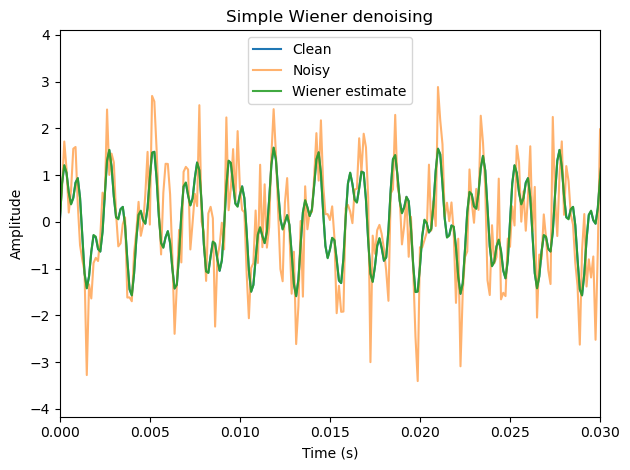

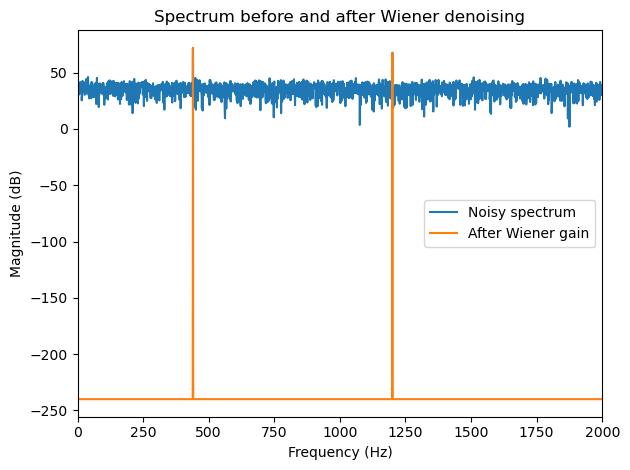

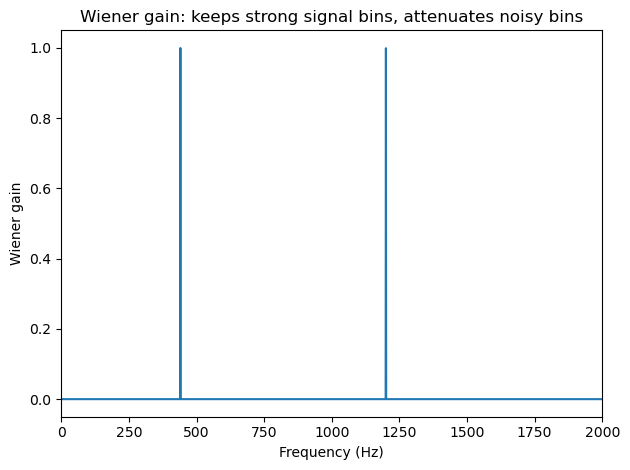

In [10]:

import numpy as np 
# This section demonstrates the basic Wiener gain:
#
#     W[k] = Sx[k] / (Sx[k] + Sn[k])
#
# This is different from Wiener deconvolution.

# Here we are not trying to undo a room response H[k].
# We are only trying to suppress noise in frequency bins where noise dominates.



# Create a synthetic clean signal
fs_demo = 8000
dur_demo = 1.0
t_demo = np.arange(int(fs_demo * dur_demo)) / fs_demo

# Clean signal: two sinusoids
x_clean = (
    np.sin(2 * np.pi * 440 * t_demo)
    + 0.6 * np.sin(2 * np.pi * 1200 * t_demo)
)

# Add white Gaussian noise
rng = np.random.default_rng(0)
noise_std = 0.8
noise = rng.normal(0.0, noise_std, size=x_clean.shape)
y_noisy = x_clean + noise

# FFT
N = len(x_clean)
X = np.fft.rfft(x_clean)
Y = np.fft.rfft(y_noisy)
f = np.fft.rfftfreq(N, d=1 / fs_demo)

# In real problems, Sx and Sn are usually unknown and must be estimated.
Sx = np.abs(X) ** 2
Sn = N * noise_std**2 * np.ones_like(Sx)

# Wiener denoising gain
W = Sx / (Sx + Sn)

# Apply Wiener gain to noisy spectrum
Xhat = W * Y
x_hat = np.fft.irfft(Xhat, n=N)

# Plot time-domain signals

plt.figure()
plt.plot(t_demo, x_clean, label="Clean")
plt.plot(t_demo, y_noisy, label="Noisy", alpha=0.6)
plt.plot(t_demo, x_hat, label="Wiener estimate", alpha=0.9)
plt.xlim(0, 0.03)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simple Wiener denoising")
plt.legend()
plt.tight_layout()
plt.show()

# %%
# Plot magnitude spectra

plt.figure()
plt.plot(f, 20*np.log10(np.abs(Y) + 1e-12), label="Noisy spectrum")
plt.plot(f, 20*np.log10(np.abs(Xhat) + 1e-12), label="After Wiener gain")
plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spectrum before and after Wiener denoising")
plt.legend()
plt.tight_layout()
plt.show()


# Plot Wiener gain

plt.figure()
plt.plot(f, W)
plt.xlim(0, 2000)
plt.ylim(-0.05, 1.05)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Wiener gain")
plt.title("Wiener gain: keeps strong signal bins, attenuates noisy bins")
plt.tight_layout()
plt.show()